In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import warnings  
import matplotlib.pyplot as plt 
import seaborn as sns

# Ignore all warnings  
warnings.filterwarnings('ignore') 

In [7]:
books = pd.read_csv(
    '/home/ahana/Book_Recommendation_System/data/raw/books.csv',
    sep=';',
    encoding='latin1',
    on_bad_lines='skip',
    low_memory=False
)

ratings = pd.read_csv(
    '/home/ahana/Book_Recommendation_System/data/raw/ratings.csv',
    sep=';',
    encoding='latin1',
    on_bad_lines='skip',
    low_memory=False
)
users = pd.read_csv(
    '/home/ahana/Book_Recommendation_System/data/raw/users.csv',
    sep=';',
    encoding='latin1',
    on_bad_lines='skip',
    low_memory=False
)

In [8]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [9]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [10]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [11]:
print("Missing values in Books Dataset:")
print(books.isnull().sum(), "\n")

print("Missing values in Users Dataset:")
print(users.isnull().sum(), "\n")

print("Missing values in Ratings Dataset:")
print(ratings.isnull().sum())

Missing values in Books Dataset:
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64 

Missing values in Users Dataset:
User-ID          0
Location         0
Age         110762
dtype: int64 

Missing values in Ratings Dataset:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


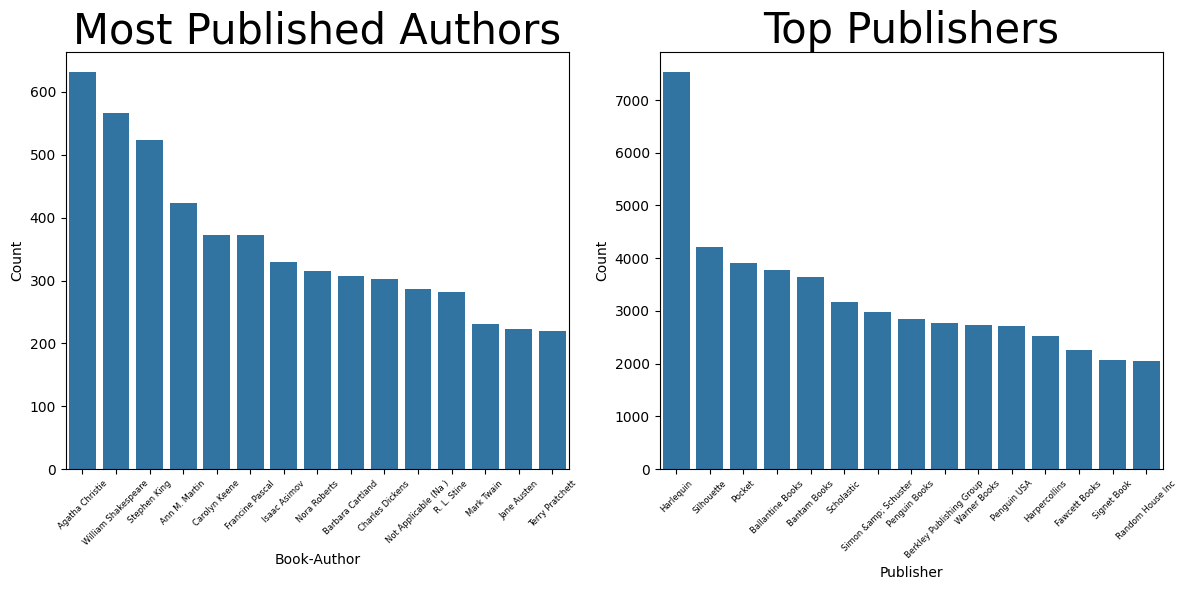

In [13]:
author_count = books['Book-Author'].value_counts().reset_index(name='Count').sort_values('Count', ascending=False).head(15)

publisher_count = books['Publisher'].value_counts().reset_index(name='Count').sort_values('Count', ascending=False).head(15)

fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,6))

ax1 = sns.barplot(data=author_count, x='Book-Author', y='Count', ax=ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, fontsize=6)
ax1.set_title('Most Published Authors', size=30)

ax2 = sns.barplot(data=publisher_count, x='Publisher', y='Count', ax=ax2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, fontsize=6)
ax2.set_title('Top Publishers', size=30)

plt.tight_layout()

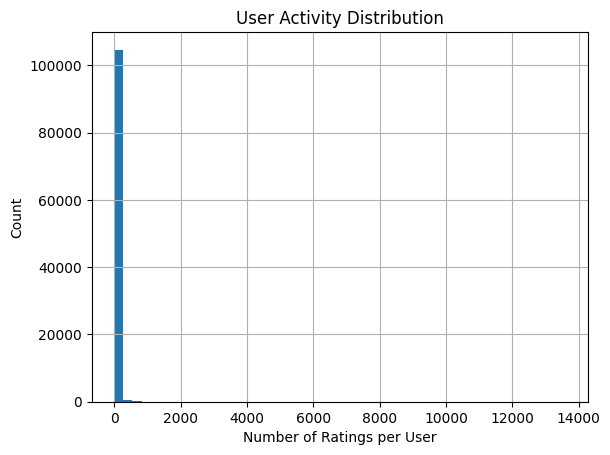


Active Users (>200 ratings):
899


In [31]:
user_activity = ratings.groupby("User-ID")["Book-Rating"].count()

plt.figure()
user_activity.hist(bins=50)
plt.title("User Activity Distribution")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Count")
plt.show()

print("\nActive Users (>200 ratings):")
print((user_activity > 200).sum())

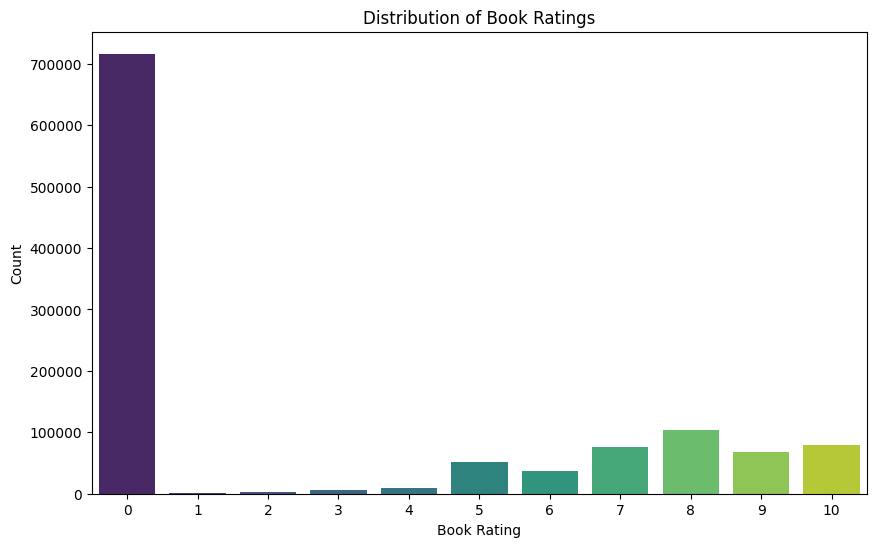

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Book-Rating', data=ratings, palette='viridis')
plt.title("Distribution of Book Ratings")
plt.xlabel("Book Rating")
plt.ylabel("Count")
plt.show()

In [26]:
merged = ratings.merge(books, on="ISBN")

rating_count = merged.groupby("Book-Title")["Book-Rating"].count().reset_index()
rating_count.rename(columns={"Book-Rating":"num_ratings"}, inplace=True)

top_books = rating_count.sort_values("num_ratings", ascending=False).head(10)

print("\nTop 10 Most Rated Books:")
print(top_books)



Top 10 Most Rated Books:
                                             Book-Title  num_ratings
234951                                      Wild Animus         2502
196326                        The Lovely Bones: A Novel         1295
183573                                The Da Vinci Code          898
5303                                    A Painted House          838
199237                       The Nanny Diaries: A Novel          828
27922                             Bridget Jones's Diary          815
206502                          The Secret Life of Bees          774
52983   Divine Secrets of the Ya-Ya Sisterhood: A Novel          740
204387              The Red Tent (Bestselling Backlist)          723
14392                               Angels &amp; Demons          670


In [28]:
author_counts = books["Book-Author"].value_counts().head(10)

print("\nTop Authors:")
print(author_counts)


Top Authors:
Book-Author
Agatha Christie        632
William Shakespeare    567
Stephen King           524
Ann M. Martin          423
Carolyn Keene          373
Francine Pascal        372
Isaac Asimov           330
Nora Roberts           315
Barbara Cartland       307
Charles Dickens        302
Name: count, dtype: int64


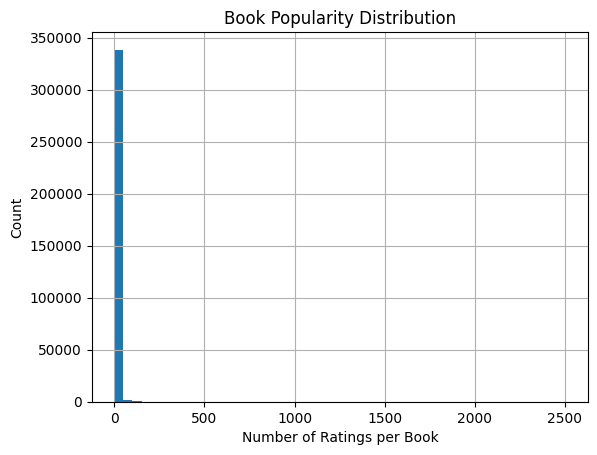


Popular Books (>50 ratings):
2125


In [29]:
book_activity = ratings.groupby("ISBN")["Book-Rating"].count()

plt.figure()
book_activity.hist(bins=50)
plt.title("Book Popularity Distribution")
plt.xlabel("Number of Ratings per Book")
plt.ylabel("Count")
plt.show()

print("\nPopular Books (>50 ratings):")
print((book_activity > 50).sum())

* The utility matrix is sparse.
* Few users are highly active and few books dominate ratings.